# 01 — Data quality & exploratory analysis

**Goal.** Understand the student data before modelling, and decide which columns can be trusted as predictors of the final exam score.

**Questions**
1. Is the data complete, consistent and plausible?
2. Which columns are *derived from the target* and would leak it into a model?
3. Which factors are associated with the exam score, and how strongly?
4. Can the session-level interaction log (`learning_interactions.csv`) be joined to the student table in a meaningful way?

| File | Grain | Rows |
|---|---|---|
| `data/raw/student_performance.csv` | 1 row per student | 1,000 |
| `data/raw/learning_interactions.csv` | 1 row per learning session | 9,000 |

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from config import LEARNING_INTERACTIONS_CSV
from ml.data import (BOUNDED_0_100, CATEGORICAL_FEATURES, NUMERIC_FEATURES, TARGET,
                     clean_student_performance, load_student_performance, score_to_level)
from ml.viz import BLUE, LEVEL_COLORS, NEUTRAL, ORANGE, SEQUENTIAL_BLUE, TEXT_MUTED, save, set_style

set_style()
pd.set_option("display.precision", 2)

## 1. Load and inspect the raw data

In [2]:
raw = load_student_performance()
print(raw.shape)
raw.head()

(1000, 20)


,student_id,score_global,grade,success_label,previous_score,math_prev_score,science_prev_score,language_prev_score,heures_etude_jour,taux_presence,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation,exam_anxiety_score,niveau_parent,style_apprentissage,niveau,derniere_activite
0,S0001,60.14,D,1,60.60,61.49,53.57,64.97,1.43,75.74,68.53,6.81,3.31,65.06,4.15,6.10,Master,Noisy,moyen,2024-01-01
1,S0002,99.02,A,1,92.29,85.61,91.87,89.04,4.81,89.60,91.99,5.57,4.93,76.02,8.71,1.98,High School,Quiet,fort,2024-01-01
2,S0003,70.52,C,1,80.26,82.16,72.74,74.24,1.24,81.50,69.67,6.70,5.11,113.62,5.93,4.46,High School,Moderate,bien,2024-01-01
3,S0004,63.45,D,1,72.93,75.98,76.73,67.72,2.19,71.47,71.98,7.85,3.77,108.69,4.22,4.74,High School,Noisy,moyen,2024-01-01
4,S0005,66.48,C,1,48.58,51.38,48.99,46.15,2.19,64.28,68.94,7.66,1.90,42.11,9.51,1.14,Master,Quiet,moyen,2024-01-01


In [3]:
raw.dtypes.value_counts()

float64    13
str         6
int64       1
Name: count, dtype: int64

## 2. Data quality checks

### 2.1 Missing values and duplicates

In [4]:
quality = pd.DataFrame({
    "missing": raw.isna().sum(),
    "unique": raw.nunique(),
    "dtype": raw.dtypes.astype(str),
})
print(f"Duplicated rows: {raw.duplicated().sum()} | duplicated student_id: {raw['student_id'].duplicated().sum()}")
quality.T

Duplicated rows: 0 | duplicated student_id: 0


,student_id,score_global,grade,success_label,previous_score,math_prev_score,science_prev_score,language_prev_score,heures_etude_jour,taux_presence,homework_completion_rate,sleep_hours,screen_time_hours,physical_activity_minutes,motivation,exam_anxiety_score,niveau_parent,style_apprentissage,niveau,derniere_activite
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
unique,1000,983,5,2,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,805,3,3,4,42
dtype,str,float64,str,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str,str,str,str


### 2.2 Impossible values
Scores and rates are percentages, so anything outside [0, 100] is an error.

In [5]:
clean_cols = {"score_global": "exam_score", "math_prev_score": "math_prev_score", "science_prev_score": "science_prev_score",
              "language_prev_score": "language_prev_score", "taux_presence": "attendance_rate",
              "homework_completion_rate": "homework_completion_rate", "previous_score": "previous_score"}
out_of_range = {new: int(((raw[old] < 0) | (raw[old] > 100)).sum()) for old, new in clean_cols.items()}
pd.Series(out_of_range, name="values outside [0, 100]").to_frame()

,"values outside [0, 100]"
exam_score,0
math_prev_score,6
science_prev_score,11
language_prev_score,8
attendance_rate,0
homework_completion_rate,47
previous_score,0


### 2.3 Signs that the data is synthetic

In [6]:
print("Students per last-activity date:", raw["derniere_activite"].value_counts().describe()[["min", "max"]].to_dict())
for col in ["niveau_parent", "style_apprentissage"]:
    print(col, raw[col].value_counts(normalize=True).round(2).to_dict())

Students per last-activity date: {'min': 16.0, 'max': 24.0}
niveau_parent {'Master': 0.35, 'High School': 0.33, 'Bachelor': 0.32}
style_apprentissage {'Quiet': 0.34, 'Moderate': 0.34, 'Noisy': 0.33}


**Findings**
- No missing values and no duplicates.
- 72 values above 100 (for example `homework_completion_rate` reaches 110%). They're **clipped to [0, 100]** during cleaning rather than dropped, because the rest of each row is valid.
- `derniere_activite` is a date sequence with about 24 students per day, and categorical variables are almost perfectly balanced. **The dataset is very likely synthetic.** Conclusions describe this simulated population, not real students.

## 3. Leakage audit: which columns are just the target in disguise?

The raw file contains `grade`, `success_label` and `niveau` alongside the exam score. If any of them is a deterministic function of the score, using it as a feature would let the model "see" the answer.

In [7]:
score = raw["score_global"]
summary = []
for col in ["grade", "success_label", "niveau"]:
    ranges = raw.groupby(col)["score_global"].agg(["min", "max"]).sort_values("min")
    overlaps = int((ranges["min"].iloc[1:].values < ranges["max"].iloc[:-1].values).sum())
    summary.append({"column": col, "categories": len(ranges), "overlapping score ranges": overlaps})
    display(ranges.round(1).T)
pd.DataFrame(summary)

grade,F,D,C,B,A
min,37.4,50.0,65.0,80.0,90.2
max,50.0,64.9,80.0,89.9,100.0


success_label,0,1
min,37.4,50.0
max,50.0,100.0


niveau,faible,moyen,bien,fort
min,37.4,50.0,70.0,85.1
max,50.0,69.8,85.0,100.0


,column,categories,overlapping score ranges
0,grade,5,0
1,success_label,2,0
2,niveau,4,0


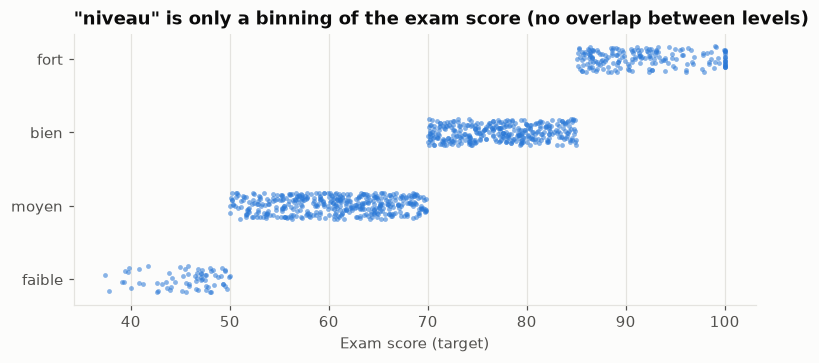

In [8]:
order = raw.groupby("niveau")["score_global"].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 3.2))
rng = np.random.default_rng(0)
for i, level in enumerate(order):
    values = raw.loc[raw["niveau"] == level, "score_global"]
    ax.scatter(values, i + rng.uniform(-0.18, 0.18, len(values)), s=10, color=BLUE, alpha=0.55, linewidths=0)
ax.set_yticks(range(len(order)), order)
ax.set_xlabel("Exam score (target)")
ax.set_title('"niveau" is only a binning of the exam score (no overlap between levels)')
ax.grid(axis="y", visible=False)
save(fig, "leakage_niveau_vs_score")
plt.show()

**Finding.** `niveau` (`faible` < 50 ≤ `moyen` < 70 ≤ `bien` < 85 ≤ `fort`), `grade` and `success_label` (= score ≥ 50) are all **deterministic functions of the target**. The original project used `niveau` as a "prior level" feature, which explains most of its ~97% accuracy. All three are **excluded from the features**.

## 4. Clean dataset

In [9]:
df = clean_student_performance(raw)
df["level"] = score_to_level(df[TARGET])
print(df.shape)
df[NUMERIC_FEATURES + [TARGET]].describe().T

(1000, 21)


,count,mean,std,min,25%,50%,75%,max
previous_score,1000.0,66.96,16.07,40.25,52.98,67.32,80.94,94.98
study_hours_per_day,1000.0,2.98,1.16,1.00,1.99,2.93,3.97,5.00
attendance_rate,1000.0,73.28,9.53,47.45,66.26,73.33,80.23,99.11
homework_completion_rate,1000.0,79.61,12.09,51.60,69.96,79.39,89.59,100.00
sleep_hours,1000.0,6.96,0.68,4.50,6.52,6.98,7.41,9.35
screen_time_hours,1000.0,3.48,1.40,1.00,2.32,3.47,4.62,5.98
physical_activity_minutes,1000.0,75.91,25.78,30.22,54.08,75.82,98.51,119.97
motivation,1000.0,6.97,1.78,4.00,5.43,6.91,8.58,9.99
exam_anxiety,1000.0,3.17,1.81,1.00,1.37,3.10,4.60,8.54
exam_score,1000.0,70.94,14.38,37.36,60.08,70.67,81.83,100.00


### 4.1 Redundant columns
`previous_score` looks like the average of the three subject scores.

In [10]:
subject_mean = df[["math_prev_score", "science_prev_score", "language_prev_score"]].mean(axis=1)
print(f"corr(previous_score, mean of subject scores) = {df['previous_score'].corr(subject_mean):.3f}")

corr(previous_score, mean of subject scores) = 0.985


With r = 0.985, the three subject scores add almost nothing beyond `previous_score`. Only `previous_score` is kept, which makes the model simpler and easier to read.

## 5. Target: exam score and learner level

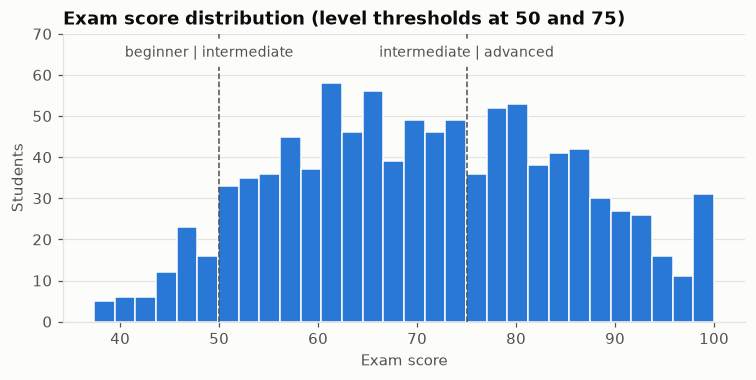

,share
level,
beginner,0.07
intermediate,0.53
advanced,0.40


In [11]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(df[TARGET], bins=30, color=BLUE, edgecolor="#fcfcfb", linewidth=1)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
for threshold in (50, 75):
    ax.axvline(threshold, color=TEXT_MUTED, linestyle="--", linewidth=1)
ax.text(49, ax.get_ylim()[1] * 0.92, "beginner | intermediate", ha="center", color=TEXT_MUTED, fontsize=9, backgroundcolor="#fcfcfb")
ax.text(75, ax.get_ylim()[1] * 0.92, "intermediate | advanced", ha="center", color=TEXT_MUTED, fontsize=9, backgroundcolor="#fcfcfb")
ax.set_xlabel("Exam score")
ax.set_ylabel("Students")
ax.set_title("Exam score distribution (level thresholds at 50 and 75)")
ax.grid(axis="x", visible=False)
save(fig, "target_distribution")
plt.show()

df["level"].value_counts(normalize=True).reindex(["beginner", "intermediate", "advanced"]).rename("share").to_frame()

The score is roughly unimodal (mean ≈ 71). The levels are **imbalanced**: only **7% beginners**. Any evaluation of the level must use macro-averaged metrics, not accuracy alone.

## 6. What is associated with the exam score?
### 6.1 Numeric factors

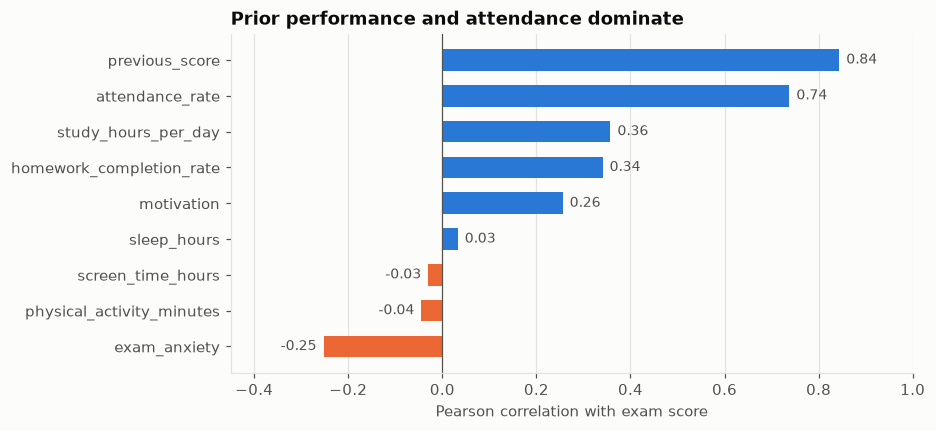

In [12]:
corr = df[NUMERIC_FEATURES].corrwith(df[TARGET]).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
colors = [BLUE if v >= 0 else ORANGE for v in corr]
ax.barh(corr.index, corr.values, color=colors, height=0.6)
for y, v in enumerate(corr.values):
    ax.text(v + (0.015 if v >= 0 else -0.015), y, f"{v:.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=9, color=TEXT_MUTED)
ax.axvline(0, color=TEXT_MUTED, linewidth=0.8)
ax.set_xlim(-0.45, 1.0)
ax.set_xlabel("Pearson correlation with exam score")
ax.set_title("Prior performance and attendance dominate")
ax.grid(axis="y", visible=False)
save(fig, "feature_correlations")
plt.show()

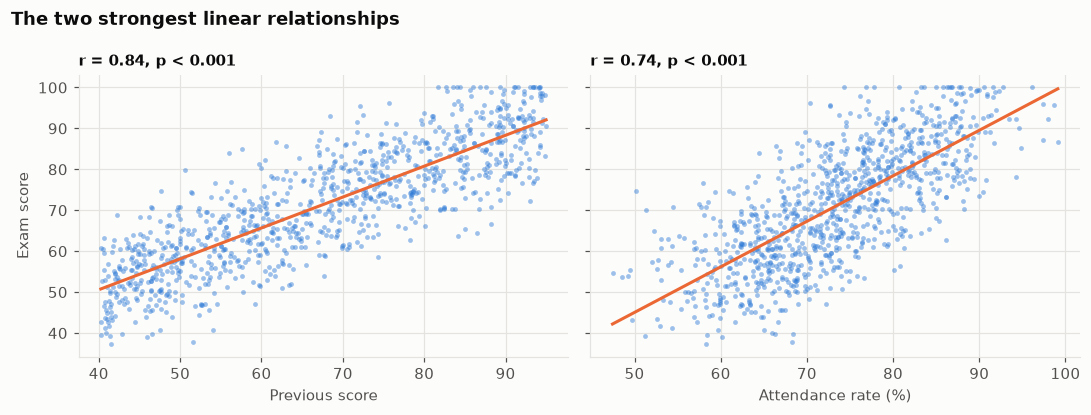

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, col, label in zip(axes, ["previous_score", "attendance_rate"], ["Previous score", "Attendance rate (%)"]):
    ax.scatter(df[col], df[TARGET], s=10, alpha=0.45, color=BLUE, linewidths=0)
    slope, intercept, r, p, _ = stats.linregress(df[col], df[TARGET])
    xs = np.linspace(df[col].min(), df[col].max(), 50)
    ax.plot(xs, intercept + slope * xs, color=ORANGE)
    ax.set_xlabel(label)
    ax.set_title(f"r = {r:.2f}, p < 0.001", fontsize=10)
axes[0].set_ylabel("Exam score")
fig.suptitle("The two strongest linear relationships", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

- `previous_score` (r = 0.84) and `attendance_rate` (r = 0.74) are the strongest signals, followed by study time, homework and motivation (≈ 0.25–0.36). These two are also correlated with each other (r = 0.85), so they carry largely the **same** information.
- `exam_anxiety` is **negatively** associated (r = −0.25).
- Sleep, screen time and physical activity show **no linear association** (|r| < 0.05).
- These are correlations in observational (and synthetic) data, **not causal effects**.

### 6.2 Categorical factors — are the group differences significant?

In [14]:
rows = []
for col in CATEGORICAL_FEATURES:
    groups = [g[TARGET].values for _, g in df.groupby(col)]
    h, p = stats.kruskal(*groups)
    means = df.groupby(col)[TARGET].mean().round(1).to_dict()
    rows.append({"variable": col, "mean score by group": means, "Kruskal-Wallis H": round(h, 2), "p-value": round(p, 3)})
pd.DataFrame(rows)

,variable,mean score by group,Kruskal-Wallis H,p-value
0,parent_education,"{'Bachelor': 71.6, 'High School': 70.7, 'Maste...",1.39,0.50
1,study_environment,"{'Moderate': 71.6, 'Noisy': 70.3, 'Quiet': 70.9}",1.55,0.46


Kruskal-Wallis is used rather than ANOVA because it doesn't assume normal residuals or equal variances. Neither parental education nor study environment shows a significant difference at α = 0.05 (see the p-values above). They're kept in the model because they cost little and the model can give them near-zero weight, but they shouldn't be presented as drivers.

## 7. Can the session log be used?

`learning_interactions.csv` records 30 sessions for each of 300 students (quiz scores, time spent, video completion…). The original project merged it with the student table on `student_id` and invented a `topic` column by cycling through a list. Before using it, check whether session behaviour relates to the exam score at all.

In [15]:
sessions = pd.read_csv(LEARNING_INTERACTIONS_CSV)
print(sessions.shape, "| students:", sessions["student_id"].nunique(),
      "| sessions per student:", sessions.groupby("student_id").size().unique())

per_student = (sessions.groupby("student_id")[["quiz_score", "assignment_score", "video_watched_percent",
                                                "time_spent_minutes", "attention_score"]].mean()
               .join(df.set_index("student_id")[TARGET], how="inner"))
session_corr = per_student.drop(columns=TARGET).corrwith(per_student[TARGET]).rename("corr with exam score")
session_corr.to_frame().round(3)

(9000, 23) | students: 300 | sessions per student: [30]


,corr with exam score
quiz_score,-3.60e-02
assignment_score,-1.00e-03
video_watched_percent,1.00e-03
time_spent_minutes,1.80e-02
attention_score,5.30e-02


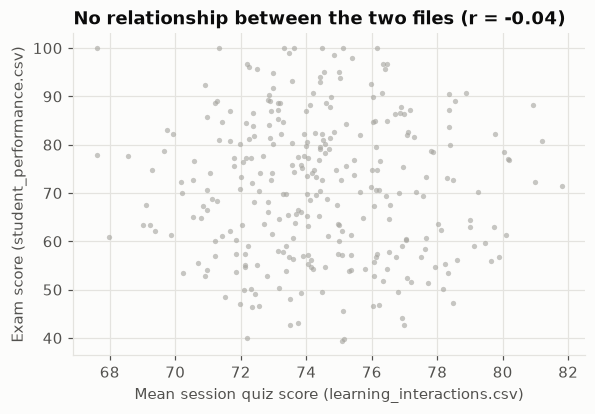

In [16]:
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.scatter(per_student["quiz_score"], per_student[TARGET], s=12, alpha=0.6, color=NEUTRAL, linewidths=0)
ax.set_xlabel("Mean session quiz score (learning_interactions.csv)")
ax.set_ylabel("Exam score (student_performance.csv)")
ax.set_title(f"No relationship between the two files (r = {session_corr['quiz_score']:.2f})")
save(fig, "sessions_vs_exam_score")
plt.show()

**Finding.** Aggregated session behaviour has **no correlation with the exam score** (|r| < 0.06 for every variable). The two files share student IDs but were generated independently. Merging them adds 30 duplicated copies of each student's target and no signal. **The session log is excluded from modelling.**

## 8. Conclusions

| Decision | Reason |
|---|---|
| Model the **exam score** (regression) from the student table only, 1 row = 1 student | Correct statistical unit, no duplicated targets |
| Drop `niveau`, `grade`, `success_label` | Deterministic functions of the target → leakage |
| Drop the three subject scores | Redundant with `previous_score` (r = 0.985) |
| Clip 72 out-of-range percentages | Physically impossible values, rest of row valid |
| Exclude `learning_interactions.csv` | Unrelated to the exam score |
| Evaluate levels with macro-F1 | Only 7% beginners |

**Limitations.** The data appears synthetic, so effect sizes and model scores describe the simulation and shouldn't be expected to transfer to a real cohort. Relationships are correlational.

→ Next: `02_modeling.ipynb`.